In [1]:
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path
from qsmp import tree
from spectrum import MultiTapering
from matplotlib.gridspec import GridSpec

In [2]:
plt.rcParams.update({
    "text.usetex": True,    
    "font.size": 12
})
img_dir = Path('../results/img/')

In [3]:
data_file = Path('../data/morlet/morlet_signal.npz')
with np.load(data_file, allow_pickle=True) as data:
    T = data['T']
    fs = data['fs']
    wave_len = data['wave_len']

In [4]:
in_file = Path('../results/morlet/qsmp_m-512_sigma-0.9_1.0_1.1_1.2_2.0_rect-50_minfilt-256.npz')
with np.load(in_file) as data:
    density = data['density'].T
    NNdist = data['profile'].T
    NNindex = data['indices'].T

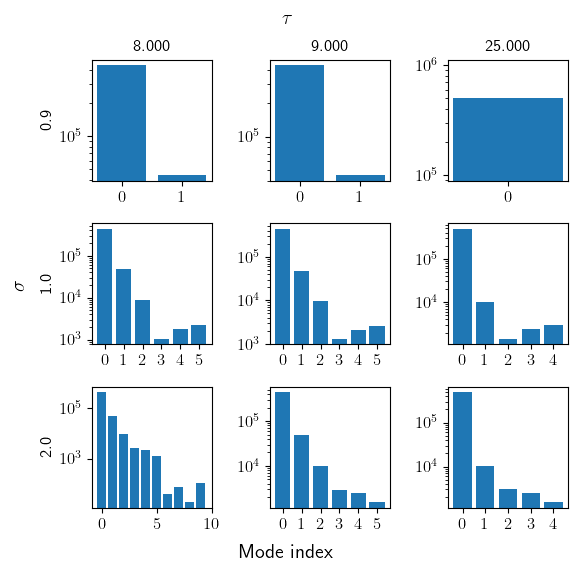

In [133]:
max_dists = np.r_[8, 9, 25]
max_modes, n_neighbors = 10, 9
subseq_len = 512
sigmas = [0.9, 1.0, 2.0]
i_sigma = [0, 1, 4]
n_sigmas, n_dists = len(sigmas), max_dists.size
fig, ax = plt.subplots(n_sigmas, n_dists, figsize=(2*n_dists, 2*n_sigmas))

for i, sigma in enumerate(sigmas):
    for j, max_dist in enumerate(max_dists):
        
        NNd, NNi, modes, cluster_size = tree.tree2clusters(
            subseq_len, density[i_sigma[i]], NNindex[i_sigma[i]],
            NNdist[i_sigma[i]], max_dist
        )

        sample, idx = tree.get_neighbors(
            T, subseq_len, density[i_sigma[i]], NNi,
            NNd, modes, max_modes, n_neighbors
        )
        ax[i,j].bar(np.arange(modes.size), cluster_size)
        if modes.size > 6:
            xticks = np.linspace(0, modes.size, 3).astype(int)
        else:
            xticks = np.arange(modes.size)
            
        ax[i,j].set_xticks(xticks)
        ax[i,j].set_yscale('log')
        if i == 0:
            ax[i,j].set_title(f'{max_dist:.3f}', fontsize=12)
        if j == 0:
            ax[i,j].set_ylabel(f'{sigma:.1f}', fontsize=12)
        

st = fig.suptitle('$\\tau$')
xx, yy = st.get_position()
st.set_position((xx, yy-0.02))
sx = fig.supxlabel('Mode index')
xx, yy = sx.get_position()
sx.set_position((xx, yy+0.03))
sy = fig.supylabel('$\sigma$')
xx, yy = sy.get_position()
sy.set_position((xx+0.02, yy))
plt.tight_layout()
fpath = img_dir.joinpath('morlet_hist_sigma_tau.pdf')
plt.savefig(fpath, bbox_inches='tight', pad_inches=0)

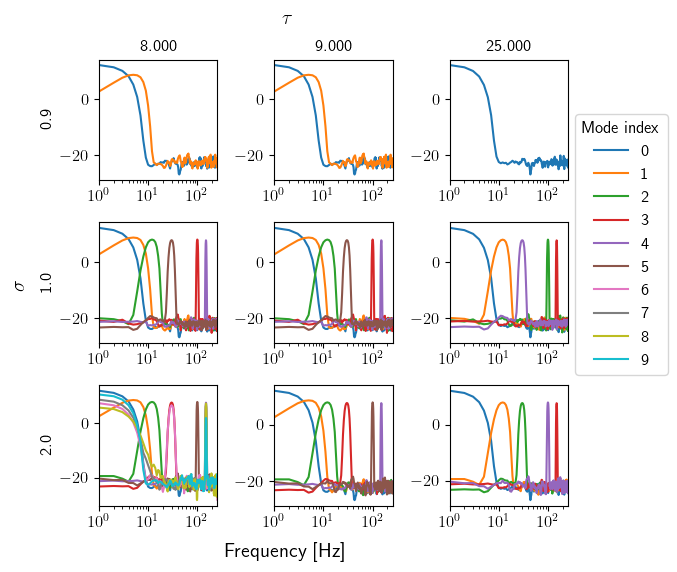

In [134]:
max_modes, n_neighbors = 10, 4
subseq_len = 512
n_sigmas, n_dists = len(sigmas), max_dists.size
fig, ax = plt.subplots(n_sigmas, n_dists, figsize=(2*n_dists, 2*n_sigmas))
f = np.arange(1,257)  # start from 1 to ease viz of logx
colors = list(mcolors.TABLEAU_COLORS.values())

for i, sigma in enumerate(sigmas):
    for j, max_dist in enumerate(max_dists):
        
        NNd, NNi, modes, cluster_size = tree.tree2clusters(
            subseq_len, density[i_sigma[i]], NNindex[i_sigma[i]],
            NNdist[i_sigma[i]], max_dist
        )

        sample, idx = tree.get_neighbors(
            T, subseq_len, density[i_sigma[i]], NNi,
            NNd, modes, max_modes, n_neighbors
        )        
        
        for mode_idx, cluster in enumerate(sample):
            tmp_PSD = np.zeros((len(cluster), subseq_len//2+1))
            for k in range(len(cluster)): #range(1):#
                X = MultiTapering(cluster[k], NW=3, sampling=512)
                tmp_PSD[k] = X.psd
            mean_PSD = np.mean(tmp_PSD, axis=0)[1:]
            # mean_PSD = tmp_PSD[0]
            ax[i,j].plot(f, 10*np.log10(mean_PSD), color=colors[mode_idx], label=f'{mode_idx}')
        
        ax[i,j].set_xlim([f[0], f[-1]])
        ax[i,j].set_xscale('log')
        
        if i == 0:
            ax[i,j].set_title(f'{max_dist:.3f}', fontsize=12)
        if j == 0:
            ax[i,j].set_ylabel(f'{sigma:.1f}', fontsize=12)
        
i_max = np.argmax([len(a.get_lines()) for a in ax.flatten()])
handles, labels = ax.flatten()[i_max].get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(1.15,0.8), bbox_transform=fig.transFigure, title='Mode index')
st = fig.suptitle('$\\tau$')
xx, yy = st.get_position()
st.set_position((xx, yy-0.02))
sx = fig.supxlabel('Frequency [Hz]')
xx, yy = sx.get_position()
sx.set_position((xx, yy+0.03))
sy = fig.supylabel('$\sigma$')
xx, yy = sy.get_position()
sy.set_position((xx+0.02, yy))
plt.tight_layout()
fpath = img_dir.joinpath('average_PSD_Morlet_sigma_tau.pdf')
plt.savefig(fpath, bbox_inches='tight', pad_inches=0)

In [167]:
data_file = Path('../data/study019-preictal/qsmp_T_splice.npz')
with np.load(data_file, allow_pickle=True) as data:
    T = data['T']

In [168]:
in_file = Path('../results/study019-preictal/qsmp_m-512_sigma-0.9_1.0_2.0_4.0_6.0_8.0_12.0_16.0_rect-50_minfilt-256.npz')
with np.load(in_file) as data:
    density = data['density'].T
    NNdist = data['profile'].T
    NNindex = data['indices'].T

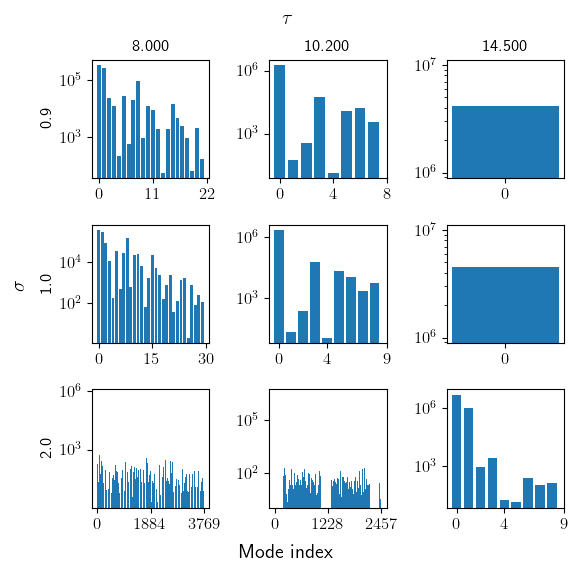

In [205]:
max_dists = np.r_[8, 10.2, 14.5]
subseq_len = 512
sigmas = [0.9, 1.0, 2.0]
i_sigma = [0, 1, 2]
n_sigmas, n_dists = len(sigmas), max_dists.size
fig, ax = plt.subplots(n_sigmas, n_dists, figsize=(2*n_dists, 2*n_sigmas))

for i, sigma in enumerate(sigmas):
    for j, max_dist in enumerate(max_dists):
        
        NNd, NNi, modes, cluster_size = tree.tree2clusters(
            subseq_len, density[i_sigma[i]], NNindex[i_sigma[i]],
            NNdist[i_sigma[i]], max_dist
        )       
        
        ax[i,j].bar(np.arange(modes.size), cluster_size)
        if modes.size > 6:
            xticks = np.linspace(0, modes.size, 3).astype(int)
        else:
            xticks = np.arange(modes.size)
            
        ax[i,j].set_xticks(xticks)
        ax[i,j].set_yscale('log')
        if i == 0:
            ax[i,j].set_title(f'{max_dist:.3f}', fontsize=12)
        if j == 0:
            ax[i,j].set_ylabel(f'{sigma:.1f}', fontsize=12)
        

st = fig.suptitle('$\\tau$')
xx, yy = st.get_position()
st.set_position((xx, yy-0.02))
sx = fig.supxlabel('Mode index')
xx, yy = sx.get_position()
sx.set_position((xx, yy+0.03))
sy = fig.supylabel('$\sigma$')
xx, yy = sy.get_position()
sy.set_position((xx+0.02, yy))
plt.tight_layout()
fpath = img_dir.joinpath('study019-preictal_hist_sigma_tau.pdf')
plt.savefig(fpath, bbox_inches='tight', pad_inches=0)

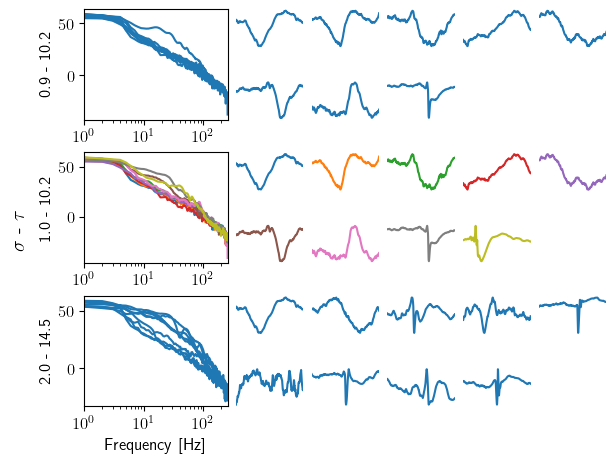

In [204]:
max_modes, n_neighbors = 10, 4
subseq_len = 512
i_sigma_tau = (
    (0, 10.2),
    (1, 10.2),
    (2, 14.5)
)
fig = plt.figure(constrained_layout = True)
gs = GridSpec(6, 7, figure=fig)
PSD_ax = [None] * 3

f = np.arange(1,257)  # start from 1 to ease viz of logx
axes = []
for i, (i_sigma, tau) in enumerate(i_sigma_tau):
            
        NNd, NNi, modes, cluster_size = tree.tree2clusters(
            subseq_len, density[i_sigma], NNindex[i_sigma],
            NNdist[i_sigma], tau
        )

        sample, idx = tree.get_neighbors(
            T, subseq_len, density[i_sigma], NNi,
            NNd, modes, max_modes, n_neighbors
        )        
        
        PSD_ax[i] = fig.add_subplot(gs[2*i:2*i+2, :2])
        for mode_idx, cluster in enumerate(sample):
            tmp_PSD = np.zeros((len(cluster), subseq_len//2+1))
            for k in range(len(cluster)): #range(1):#
                X = MultiTapering(cluster[k], NW=3, sampling=512)                
                tmp_PSD[k] = X.psd
            mean_PSD = np.mean(tmp_PSD, axis=0)[1:]
            mode_row_ind = mode_idx // (max_modes//2) + 2*i
            mode_col_ind = mode_idx % (max_modes//2) + 2
            mode_ax = fig.add_subplot(gs[mode_row_ind, mode_col_ind])
            if i == 1:
                PSD_ax[i].plot(f, 10*np.log10(mean_PSD), color=colors[mode_idx], label=f'{mode_idx}')
                mode_ax.plot(cluster[0], color=colors[mode_idx])
            else:
                PSD_ax[i].plot(f, 10*np.log10(mean_PSD), color=colors[0], label=f'{mode_idx}')
                mode_ax.plot(cluster[0])
            mode_ax.axis('off')
            mode_ax.set_xlim([0, subseq_len-1])
        PSD_ax[i].set_xlim([f[0], f[-1]])
        PSD_ax[i].set_xscale('log')
        PSD_ax[i].set_ylabel(f'{sigmas[i_sigma]:.1f} - {tau:.1f}', fontsize=12)
        
sx = PSD_ax[2].set_xlabel('Frequency [Hz]')
sy = fig.supylabel('$\sigma$ - $\\tau$')
xx, yy = sy.get_position()
sy.set_position((xx+0.02, yy))

plt.tight_layout(h_pad=0.5, w_pad=0.5)
fpath = img_dir.joinpath('average_PSD_study019-preictal_sigma_tau.pdf')
plt.savefig(fpath, bbox_inches='tight', pad_inches=0)